In [26]:
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [9]:
# Load each season's data
# Data from CollegeHockeyInc.com
stats_2022 = pd.read_csv("college_hockey_stats_2021_22.csv")
stats_2023 = pd.read_csv("college_hockey_stats_2022_23.csv")
stats_2024 = pd.read_csv("college_hockey_stats_2023_24.csv")
stats_2025 = pd.read_csv("college_hockey_stats_2024_25.csv")
stats_2026 = pd.read_csv("college_hockey_stats_2025_26.csv")

# Tag each dataframe with its season before combining
stats_2022["Season"] = "2021-22"
stats_2023["Season"] = "2022-23"
stats_2024["Season"] = "2023-24"
stats_2025["Season"] = "2024-25"
stats_2026["Season"] = "2025-26"

# Combine all five seasons into one dataframe
five_year_stats = pd.concat([stats_2022, stats_2023, stats_2024, stats_2025, stats_2026], ignore_index=True)

# Drop the rank column and any unnamed columns that come from the CSV index
five_year_stats = five_year_stats.drop(columns=["Rk"], errors="ignore")
five_year_stats = five_year_stats.loc[:, ~five_year_stats.columns.str.contains("^Unnamed")]

five_year_stats

,Name,Team,Pos.,Yr,GP,G,A,PTS,Pt/Gm,PIM,Shots,GWG,PPG,SHG,+/-,Blk,FW,FL,FO%,Season
0,Bobby Brink,Denver,F,Jr,41.0,14.0,43.0,57.0,1.3902,44.0,119.0,2.0,5.0,1.0,27.0,17.0,2.0,4.0,33.3,2021-22
1,Nathan Smith,Minnesota State,F,Jr,38.0,19.0,31.0,50.0,1.3158,43.0,101.0,4.0,3.0,0.0,22.0,11.0,329.0,243.0,57.5,2021-22
2,Julian Napravnik,Minnesota State,F,Sr,40.0,18.0,31.0,49.0,1.2250,10.0,129.0,3.0,6.0,0.0,32.0,10.0,0.0,0.0,NaN,2021-22
3,Bobby Trivigno,Massachusetts,F,Sr,37.0,20.0,29.0,49.0,1.3243,28.0,126.0,4.0,4.0,1.0,22.0,14.0,2.0,4.0,33.3,2021-22
4,Owen Sillinger,Bemidji State,F,Sr,39.0,17.0,30.0,47.0,1.2051,41.0,137.0,3.0,2.0,0.0,10.0,15.0,515.0,425.0,54.8,2021-22
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8995,Michael Simpson,Providence,G,Fr,1.0,0.0,0.0,0.0,0.0000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,2025-26
8996,Daniel Buchbinder,Mass.-Lowell,D,So,1.0,0.0,0.0,0.0,0.0000,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,2025-26
8997,Luke McCrady,Cornell,D,Fr,1.0,0.0,0.0,0.0,0.0000,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,2025-26
8998,William Troutwine,Holy Cross,D,Jr,1.0,0.0,0.0,0.0,0.0000,0.0,0.0,0.0,0.0,0.0,-1.0,0.0,0.0,0.0,NaN,2025-26


In [41]:
# Keep only F and D 
five_year_stats = five_year_stats[five_year_stats["Pos_Group"].isin(["F", "D"])].copy()

five_year_stats["Pos_Group"].value_counts()

Pos_Group
F    4950
D    2731
Name: count, dtype: int64

In [48]:
# Function to convert a stat into a 0-100 percentile rank
def percentile_rank(series):
    return series.rank(pct=True) * 100

# Calculate Pt/Gm percentile within each season and position group
five_year_stats["PtGm_pct"] = five_year_stats.groupby(["Season", "Pos_Group"])["Pt/Gm"].transform(percentile_rank)

# List of stats to percentile rank
percentile_metrics = ["G", "A", "Shots", "PPG", "SHG", "+/-", "Blk", "FO%"]

# Loop through each stat and create a percentile column
# FO% becomes FO_pct, everything else just gets _pct added
for metric in percentile_metrics:
    pct_col = metric.replace("%", "") + "_pct"
    five_year_stats[pct_col] = five_year_stats.groupby(["Season", "Pos_Group"])[metric].transform(percentile_rank)

# Quick check of the results
five_year_stats[["Name", "Season", "Pos_Group", "G", "G_pct", "Shots", "Shots_pct"]].head(10)

,Name,Season,Pos_Group,G,G_pct,Shots,Shots_pct
0,Bobby Brink,2021-22,F,14.0,93.756558,119.0,97.691501
1,Nathan Smith,2021-22,F,19.0,98.216159,101.0,93.966422
2,Julian Napravnik,2021-22,F,18.0,97.743966,129.0,98.530955
3,Bobby Trivigno,2021-22,F,20.0,98.740818,126.0,98.216159
4,Owen Sillinger,2021-22,F,17.0,97.271773,137.0,99.055614
5,Cole Guttman,2021-22,F,19.0,98.216159,141.0,99.160546
6,Drew Worrad,2021-22,F,9.0,78.856243,64.0,71.930745
7,Carter Savoie,2021-22,F,23.0,99.632739,152.0,99.737671
8,Brendan Furry,2021-22,F,13.0,92.287513,92.0,89.979014
9,Brian Halonen,2021-22,F,21.0,99.213012,132.0,98.793284


In [49]:
# Function to pull all seasons for a given player
def get_player_profile(player_name):
    player_df = five_year_stats[five_year_stats["Name"] == player_name].copy()
    
    if player_df.empty:
        print(f"Player '{player_name}' not found. Check spelling and capitalization.")
        return None
    
    player_df = player_df.sort_values("Season")
    return player_df

# Test with a specific player
heaslip = get_player_profile("Tabor Heaslip")
heaslip[["Name", "Season", "Pos_Group",
         "Pt/Gm", "PtGm_pct",
         "G", "G_pct",
         "Shots", "Shots_pct",
         "PPG", "PPG_pct",
         "Blk", "Blk_pct"]]

,Name,Season,Pos_Group,Pt/Gm,PtGm_pct,G,G_pct,Shots,Shots_pct,PPG,PPG_pct,Blk,Blk_pct
2566,Tabor Heaslip,2022-23,F,0.1714,24.196787,2.0,31.576305,47.0,54.568273,0.0,26.556225,8.0,37.600402
4188,Tabor Heaslip,2023-24,F,0.2222,26.289683,1.0,18.551587,62.0,65.972222,0.0,26.884921,24.0,91.220238
5798,Tabor Heaslip,2024-25,F,0.5385,70.969337,8.0,73.986152,73.0,79.030663,0.0,27.843719,27.0,93.818002
7666,Tabor Heaslip,2025-26,F,0.5300,67.260692,6.0,66.751527,62.0,75.916497,0.0,27.596741,30.0,98.014257


In [50]:
# Check which players appear most across seasons
five_year_stats["Name"].value_counts().head(20)

Name
Ryan Sullivan          7
Luke Johnson           7
Matt Allen             6
Kyle Aucoin            5
Jackson Niedermayer    5
Brayden Morrison       5
Reilly Funk            5
Nic Belpedio           5
Caden Brown            5
Michael Young          5
Michael Citara         5
Cam MacDonald          5
Alex Gaffney           5
Kyler Kovich           5
Keegan Langefels       4
Cole Miller            4
Oak MacLeod            4
Brayden Nicholetts     4
Nick Donato            4
Dustin Geregach        4
Name: count, dtype: int64

In [70]:
# Test with another player
get_player_profile("Ethan Wyttenbach")

,Name,Team,Pos.,Yr,GP,G,A,PTS,Pt/Gm,PIM,...,PtGm_pct,G_pct,A_pct,Shots_pct,PPG_pct,SHG_pct,+/-_pct,Blk_pct,FO_pct,Elite
7305,Ethan Wyttenbach,Quinnipiac,F,Fr,34.0,22.0,32.0,54.0,1.59,14.0,...,100.0,99.745418,100.0,92.00611,97.148676,43.839104,99.083503,48.421589,61.572536,True


In [71]:
# Ask the user to enter a player name and display their profile
player_name = input("Enter player name exactly as listed: ")
player_profile = get_player_profile(player_name)

if player_profile is not None:
    display_cols = ["Season", "Pos_Group",
                    "Pt/Gm", "PtGm_pct",
                    "G", "G_pct",
                    "Shots", "Shots_pct",
                    "PPG", "PPG_pct",
                    "Blk", "Blk_pct"]
    display(player_profile[display_cols])

Enter player name exactly as listed:  Will Horcoff


,Season,Pos_Group,Pt/Gm,PtGm_pct,G,G_pct,Shots,Shots_pct,PPG,PPG_pct,Blk,Blk_pct
6288,2024-25,F,0.5556,72.403561,4.0,47.725025,44.0,48.269041,3.0,84.371909,2.0,10.385757
7328,2025-26,F,1.0600,95.926680,22.0,99.745418,96.0,95.773931,10.0,99.796334,5.0,22.861507


<Figure size 800x400 with 0 Axes>

Text(0.5, 1.0, 'Will Horcoff — Pt/Gm Percentile Trend')

Text(0.5, 0, 'Season')

Text(0, 0.5, 'Percentile (0-100)')

(0.0, 100.0)

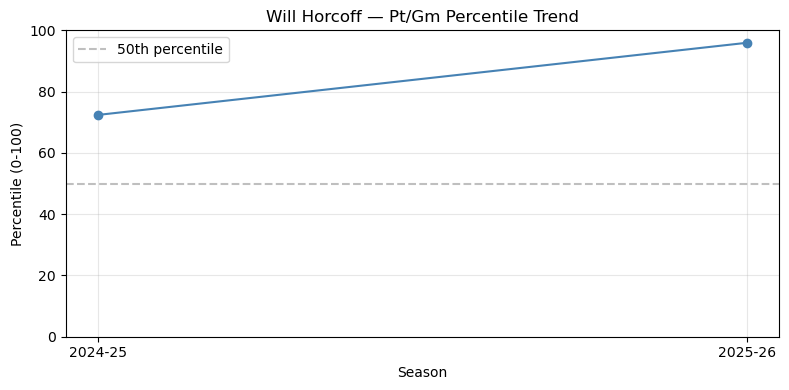

In [72]:
# Line chart showing how the player's Pt/Gm percentile has changed each season
if player_profile is not None:
    plot_df = player_profile.sort_values("Season")
    
    plt.figure(figsize=(8, 4))
    plt.plot(plot_df["Season"], plot_df["PtGm_pct"], marker="o", color="steelblue")
    plt.title(f"{player_name} — Pt/Gm Percentile Trend")
    plt.xlabel("Season")
    plt.ylabel("Percentile (0-100)")
    plt.ylim(0, 100)
    plt.axhline(50, color="gray", linestyle="--", alpha=0.5, label="50th percentile")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

<Figure size 800x400 with 0 Axes>

<BarContainer object of 7 artists>

(0.0, 100.0)

Text(0.5, 1.0, 'Will Horcoff — Percentile Profile (2025-26)')

Text(0, 0.5, 'Percentile (0-100)')

([0, 1, 2, 3, 4, 5, 6],
 [Text(0, 0, 'Goals'),
  Text(1, 0, 'Assists'),
  Text(2, 0, 'Shots'),
  Text(3, 0, 'PPG'),
  Text(4, 0, 'SHG'),
  Text(5, 0, '+/-'),
  Text(6, 0, 'Blocks')])

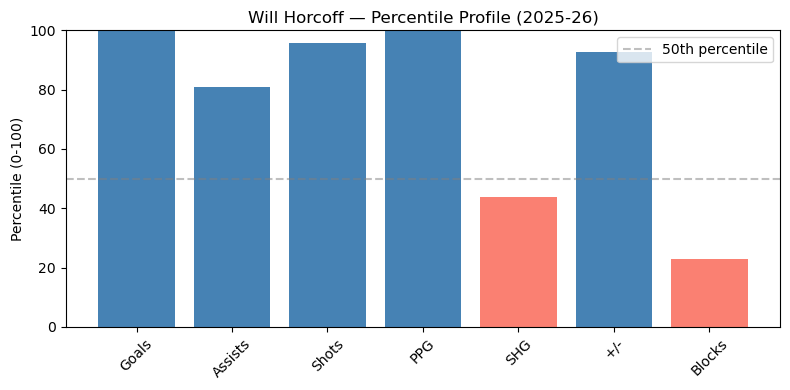

In [73]:
# Bar chart showing the player's percentile ranking across key stats for their most recent season
if player_profile is not None:
    current_season = player_profile.sort_values("Season").iloc[-1]
    
    metrics = {
        "Goals": current_season["G_pct"],
        "Assists": current_season["A_pct"],
        "Shots": current_season["Shots_pct"],
        "PPG": current_season["PPG_pct"],
        "SHG": current_season["SHG_pct"],
        "+/-": current_season["+/-_pct"],
        "Blocks": current_season["Blk_pct"]
    }
    
    # Drop any stats that don't have data for this player
    metrics = {k: v for k, v in metrics.items() if pd.notna(v)}
    
    names = list(metrics.keys())
    values = list(metrics.values())
    
    # Color bars green if above 50th percentile, red if below
    colors = ["steelblue" if v >= 50 else "salmon" for v in values]
    
    plt.figure(figsize=(8, 4))
    plt.bar(names, values, color=colors)
    plt.axhline(50, color="gray", linestyle="--", alpha=0.5, label="50th percentile")
    plt.ylim(0, 100)
    plt.title(f"{player_name} — Percentile Profile ({current_season['Season']})")
    plt.ylabel("Percentile (0-100)")
    plt.xticks(rotation=45)
    plt.legend()
    plt.tight_layout()
    plt.show()

<Figure size 800x400 with 0 Axes>

(array([ 97.,  84.,  96., 119.,  98., 104.,  87.,  66.,  59.,  48.,  40.,
         20.,  19.,  17.,   7.,   8.,   6.,   3.,   2.,   2.]),
 array([0.    , 0.0795, 0.159 , 0.2385, 0.318 , 0.3975, 0.477 , 0.5565,
        0.636 , 0.7155, 0.795 , 0.8745, 0.954 , 1.0335, 1.113 , 1.1925,
        1.272 , 1.3515, 1.431 , 1.5105, 1.59  ]),
 <BarContainer object of 20 artists>)

Text(0.5, 1.0, 'Pt/Gm Distribution — Fs in 2025-26')

Text(0.5, 0, 'Points Per Game')

Text(0, 0.5, 'Number of Players')

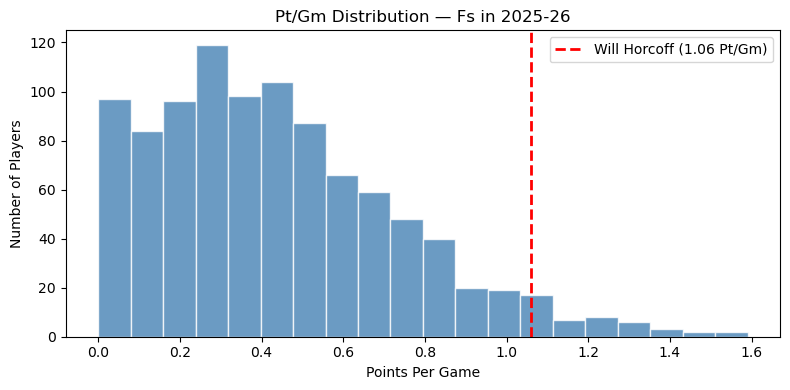

In [74]:
# Histogram showing where the player falls in the Pt/Gm distribution for their position and season
if player_profile is not None:
    current_season = player_profile.sort_values("Season").iloc[-1]
    season = current_season["Season"]
    position = current_season["Pos_Group"]
    player_value = current_season["Pt/Gm"]
    
    # Filter to same position and season
    cohort = five_year_stats[
        (five_year_stats["Season"] == season) &
        (five_year_stats["Pos_Group"] == position)
    ]
    
    plt.figure(figsize=(8, 4))
    plt.hist(cohort["Pt/Gm"], bins=20, color="steelblue", edgecolor="white", alpha=0.8)
    
    # Mark where this player lands in the distribution
    plt.axvline(player_value, color="red", linestyle="--", linewidth=2, label=f"{player_name} ({player_value:.2f} Pt/Gm)")
    
    plt.title(f"Pt/Gm Distribution — {position}s in {season}")
    plt.xlabel("Points Per Game")
    plt.ylabel("Number of Players")
    plt.legend()
    plt.tight_layout()
    plt.show()

In [75]:
# Define elite as anyone in the 90th percentile or above for Pt/Gm
elite_threshold = 90
five_year_stats["Elite"] = five_year_stats["PtGm_pct"] >= elite_threshold

# Split into two groups
elite_group = five_year_stats[five_year_stats["Elite"]]
non_elite_group = five_year_stats[~five_year_stats["Elite"]]

# Compare average percentiles across key stats between the two groups
comparison_metrics = ["G_pct", "Shots_pct", "PPG_pct", "Blk_pct"]

elite_means = elite_group[comparison_metrics].mean()
non_elite_means = non_elite_group[comparison_metrics].mean()

comparison_df = pd.DataFrame({
    "Elite Avg Percentile": elite_means,
    "Non-Elite Avg Percentile": non_elite_means
})

comparison_df

,Elite Avg Percentile,Non-Elite Avg Percentile
G_pct,88.542521,45.747111
Shots_pct,86.223462,46.007358
PPG_pct,82.882553,46.382279
Blk_pct,64.796892,48.411415


<Axes: >

Text(0.5, 1.0, 'Elite vs. Non-Elite Player Comparison')

Text(0, 0.5, 'Average Percentile (0-100)')

(0.0, 100.0)

(array([0, 1, 2, 3]),
 [Text(0, 0, 'Goals'),
  Text(1, 0, 'Shots'),
  Text(2, 0, 'Power Play Goals'),
  Text(3, 0, 'Blocks')])

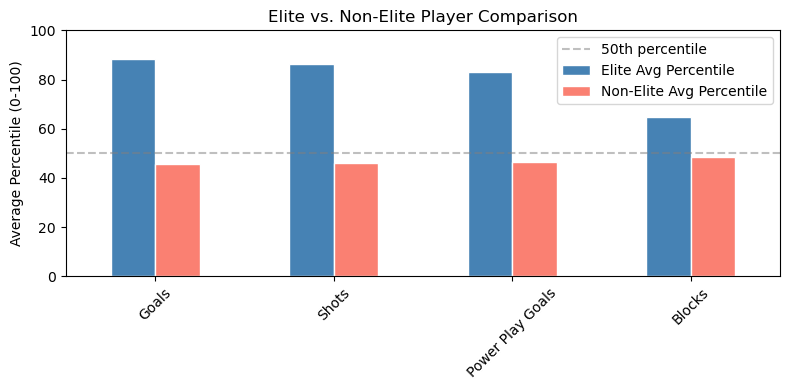

In [76]:
# Rename index to readable labels before plotting
comparison_df.index = ["Goals", "Shots", "Power Play Goals", "Blocks"]

# Bar chart comparing average percentiles between elite and non-elite players
comparison_df.plot(kind="bar", figsize=(8, 4), color=["steelblue", "salmon"], edgecolor="white")

plt.title("Elite vs. Non-Elite Player Comparison")
plt.ylabel("Average Percentile (0-100)")
plt.ylim(0, 100)
plt.xticks(rotation=45)
plt.axhline(50, color="gray", linestyle="--", alpha=0.5, label="50th percentile")
plt.legend()
plt.tight_layout()
plt.show()

In [77]:
def run_player_dashboard(player_name, min_gp=1):
    player_name = player_name.strip()

    # Pull all seasons for this player
    player_profile = five_year_stats[five_year_stats["Name"] == player_name].copy()
    if player_profile.empty:
        print("Player not found. Check spelling and spacing.")
        return

    # Filter by minimum games played
    player_profile = player_profile[player_profile["GP"] >= min_gp].copy()
    if player_profile.empty:
        print(f"Player found, but no seasons with GP >= {min_gp}.")
        return

    player_profile = player_profile.sort_values("Season")
    current = player_profile.iloc[-1]
    season = current["Season"]
    pos_group = current["Pos_Group"]

    # Print a summary header and stats table
    display_cols = [
        "Season", "Team", "Pos_Group", "Yr", "GP",
        "Pt/Gm", "PtGm_pct",
        "G", "G_pct",
        "A", "A_pct",
        "Shots", "Shots_pct",
        "PPG", "PPG_pct",
        "SHG", "SHG_pct",
        "+/-", "+/-_pct",
        "Blk", "Blk_pct",
        "FO%", "FO_pct"
    ]
    display_cols = [c for c in display_cols if c in player_profile.columns]

    teams = player_profile["Team"].dropna().unique().tolist()
    teams_str = ", ".join(teams)

    still_active = "Yes" if season == "2025-26" else "No"

    print(f"\nPlayer: {player_name}")
    print(f"Position Group: {pos_group}")
    print(f"Most Recent Season: {season}")
    print(f"Still Active: {still_active}")
    print(f"Teams: {teams_str}\n")
    display(player_profile[display_cols])

    # --- VIS 1: Pt/Gm Percentile Trend ---
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(player_profile["Season"], player_profile["PtGm_pct"], marker="o", color="steelblue")
    ax.axhline(50, color="gray", linestyle="--", alpha=0.5, label="50th percentile")
    ax.set_title(f"{player_name} — Pt/Gm Percentile Trend")
    ax.set_xlabel("Season")
    ax.set_ylabel("Percentile (0-100)")
    ax.set_ylim(0, 100)
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    # --- VIS 2: Current Season Percentile Profile ---
    metrics = {
        "Goals": current.get("G_pct", pd.NA),
        "Assists": current.get("A_pct", pd.NA),
        "Shots": current.get("Shots_pct", pd.NA),
        "PPG": current.get("PPG_pct", pd.NA),
        "SHG": current.get("SHG_pct", pd.NA),
        "+/-": current.get("+/-_pct", pd.NA),
        "Blocks": current.get("Blk_pct", pd.NA),
        "FO%": current.get("FO_pct", pd.NA),
    }
    metrics = {k: v for k, v in metrics.items() if pd.notna(v)}

    colors = ["steelblue" if v >= 50 else "salmon" for v in metrics.values()]

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.bar(list(metrics.keys()), list(metrics.values()), color=colors, edgecolor="white")
    ax.axhline(50, color="gray", linestyle="--", alpha=0.5, label="50th percentile")
    ax.set_ylim(0, 100)
    ax.set_title(f"{player_name} — Percentile Profile ({season})")
    ax.set_ylabel("Percentile (0-100)")
    ax.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    # --- VIS 3: Cohort Pt/Gm Distribution ---
    cohort = five_year_stats[
        (five_year_stats["Season"] == season) &
        (five_year_stats["Pos_Group"] == pos_group)
    ]

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.hist(cohort["Pt/Gm"], bins=20, color="steelblue", edgecolor="white", alpha=0.8)
    ax.axvline(current["Pt/Gm"], color="red", linestyle="--", linewidth=2,
               label=f"{player_name} ({current['Pt/Gm']:.2f} Pt/Gm)")
    ax.set_title(f"Pt/Gm Distribution — {pos_group}s in {season}")
    ax.set_xlabel("Points Per Game")
    ax.set_ylabel("Number of Players")
    ax.legend()
    plt.tight_layout()
    plt.show()

    # --- VIS 4: Elite vs. Non-Elite Comparison ---
    comparison_metrics = ["G_pct", "Shots_pct", "PPG_pct", "Blk_pct"]
    elite_group = five_year_stats[five_year_stats["PtGm_pct"] >= 90]
    non_elite_group = five_year_stats[five_year_stats["PtGm_pct"] < 90]

    comp = pd.DataFrame({
        "Elite Avg Percentile": elite_group[comparison_metrics].mean(),
        "Non-Elite Avg Percentile": non_elite_group[comparison_metrics].mean()
    })
    comp.index = ["Goals", "Shots", "Power Play Goals", "Blocks"]

    fig, ax = plt.subplots(figsize=(8, 4))
    comp.plot(kind="bar", ax=ax, color=["steelblue", "salmon"], edgecolor="white")
    ax.axhline(50, color="gray", linestyle="--", alpha=0.5, label="50th percentile")
    ax.set_title("Elite vs. Non-Elite Player Comparison (All Seasons)")
    ax.set_ylabel("Average Percentile (0-100)")
    ax.set_ylim(0, 100)
    ax.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

Enter player name exactly as listed:  Ryan Leonard



Player: Ryan Leonard
Position Group: F
Most Recent Season: 2024-25
Still Active: No
Teams: Boston College



,Season,Team,Pos_Group,Yr,GP,Pt/Gm,PtGm_pct,G,G_pct,A,...,PPG,PPG_pct,SHG,SHG_pct,+/-,+/-_pct,Blk,Blk_pct,FO%,FO_pct
3354,2023-24,Boston College,F,Fr,41.0,1.4634,99.404762,31.0,99.801587,29.0,...,13.0,99.751984,1.0,90.625000,36.0,100.000000,21.0,85.069444,70.0,92.630938
5555,2024-25,Boston College,F,So,37.0,1.3243,99.703264,30.0,100.000000,19.0,...,4.0,90.454995,1.0,92.037587,30.0,99.703264,20.0,82.245302,43.9,42.841530


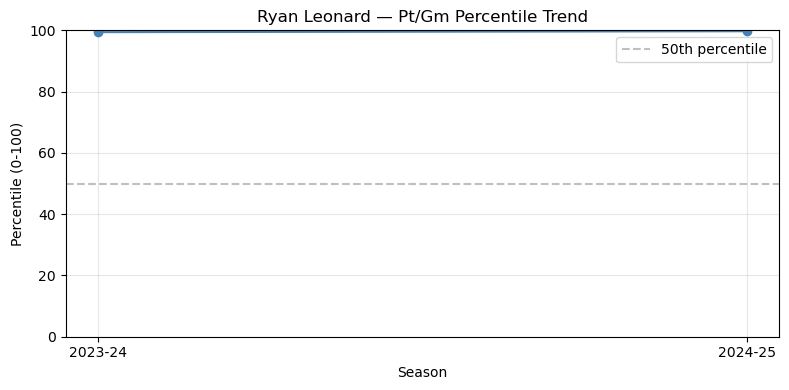

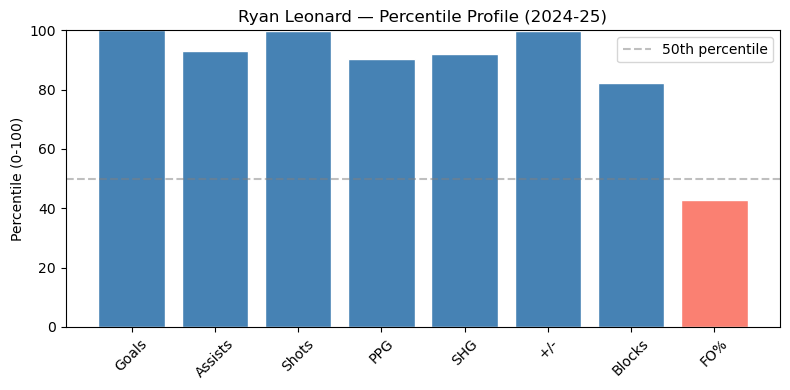

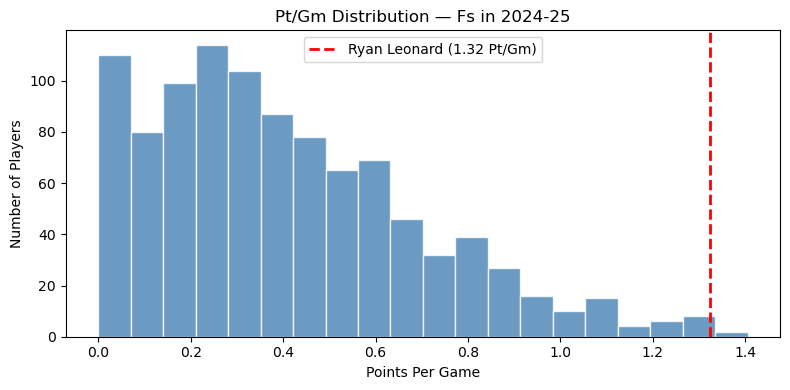

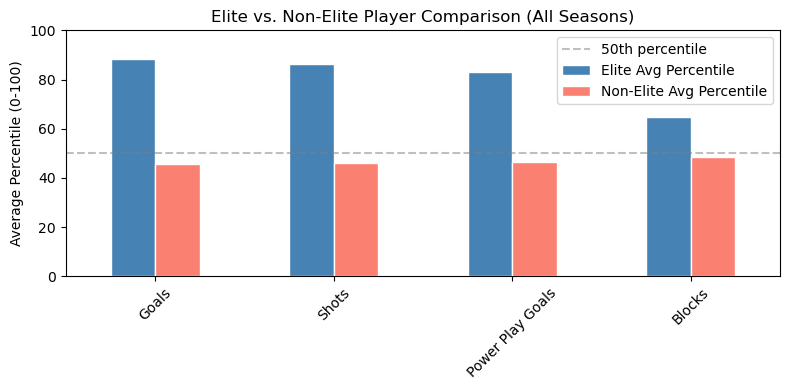

In [69]:
# Run the dashboard for a user-entered player name
player_name = input("Enter player name exactly as listed: ")
run_player_dashboard(player_name)

In [78]:
five_year_stats.to_csv("college_hockey_stats_with_percentiles.csv", index=False)